En esta práctica del módulo 34 utilizo SourceTree para registrar los cambios de este notebook y sincronizarlos con GitHub.

Este notebook forma parte de mis prácticas de análisis de datos. En el módulo 34 lo incorporé a GitHub para llevar un registro de sus cambios con Git.

# Análisis exploratorio de ventas de videojuegos

En este ejercicio realizaré un análisis exploratorio del archivo vgsales.csv. El propósito es conocer el comportamiento de las ventas de videojuegos según el año, género, plataforma y región, además de identificar algunos cambios y oportunidades de mercado.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_csv("vgsales.csv")

print("El archivo se cargó correctamente.")
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

El archivo se cargó correctamente.
Cantidad de filas: 16598
Cantidad de columnas: 11


## Revisión inicial de los datos

Para conocer la estructura del archivo, revisaré los primeros registros, los últimos y una muestra aleatoria.

In [6]:
# Primeras cinco filas
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [7]:
# Últimas cinco filas
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [8]:
# Muestra aleatoria de cinco filas
df.sample(5, random_state=42)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
8928,8930,F1 2012,PC,2012.0,Racing,Codemasters,0.01,0.11,0.00,0.03,0.15
4789,4791,"Transformers: The Game (XBox 360, PS2, PS3, Wi...",PS3,2007.0,Action,Activision,0.32,0.04,0.01,0.04,0.40
15492,15495,Commandos 3: Destination Berlin,PC,2003.0,Strategy,Eidos Interactive,0.00,0.02,0.00,0.00,0.02
14767,14770,The Sims 2: Bon Voyage,PC,2007.0,Simulation,Electronic Arts,0.01,0.01,0.00,0.00,0.03
5211,5213,Guitar Hero: Smash Hits,PS3,2009.0,Misc,Activision,0.20,0.11,0.00,0.05,0.36


## Validación de las columnas numéricas

Antes de realizar los cálculos, verificaré que las columnas relacionadas con el año, posición y ventas tengan un formato numérico.

In [9]:
columnas_numericas = [
    "Rank",
    "Year",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df[columnas_numericas].dtypes

Rank              int64
Year            float64
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

## Estadísticas descriptivas

En esta sección revisaré las principales estadísticas de las columnas numéricas, como el promedio, el valor mínimo, el máximo y los cuartiles.

In [10]:
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,16598.0,8300.605254,4791.853933,1.00,4151.25,8300.50,12449.75,16600.00
Year,16327.0,2006.406443,5.828981,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16598.0,0.264667,0.816683,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.0,0.146652,0.505351,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.0,0.077782,0.309291,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.0,0.048063,0.188588,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.0,0.537441,1.555028,0.01,0.06,0.17,0.47,82.74


## Revisión de valores faltantes

Ahora revisaré si existen datos vacíos que puedan afectar los cálculos y las gráficas del análisis.

In [11]:
valores_faltantes = df.isnull().sum()

valores_faltantes[valores_faltantes > 0]

Year         271
Publisher     58
dtype: int64

## Limpieza de los datos

Para realizar el análisis por año, eliminaré los registros que no tienen un año definido. Los nombres faltantes de las editoriales serán reemplazados por la palabra "Desconocido".

In [12]:
df_limpio = df.dropna(subset=["Year"]).copy()

df_limpio["Year"] = df_limpio["Year"].astype(int)
df_limpio["Publisher"] = df_limpio["Publisher"].fillna("Desconocido")

print("Registros originales:", len(df))
print("Registros después de la limpieza:", len(df_limpio))
print("\nValores faltantes:")
print(df_limpio.isnull().sum())

Registros originales: 16598
Registros después de la limpieza: 16327

Valores faltantes:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


## Totales generales

Calcularé la cantidad de registros, títulos diferentes, géneros y plataformas incluidos en el análisis. Un mismo videojuego puede aparecer varias veces si fue lanzado en distintas plataformas.

In [13]:
total_registros = len(df_limpio)
total_videojuegos = df_limpio["Name"].nunique()
total_generos = df_limpio["Genre"].nunique()
total_plataformas = df_limpio["Platform"].nunique()

print("Total de registros analizados:", total_registros)
print("Total de videojuegos diferentes:", total_videojuegos)
print("Total de géneros analizados:", total_generos)
print("Total de plataformas analizadas:", total_plataformas)

Total de registros analizados: 16327
Total de videojuegos diferentes: 11360
Total de géneros analizados: 12
Total de plataformas analizadas: 31


## Ventas acumuladas por año de lanzamiento

Agruparé las ventas acumuladas de los videojuegos según su año de lanzamiento, separadas en Norteamérica, Europa, Japón, otras regiones y el total global. Las cantidades están expresadas en millones de unidades, no en dinero.

In [14]:
columnas_ventas = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

ventas_por_anio = (
    df_limpio
    .groupby("Year")[columnas_ventas]
    .sum()
    .round(2)
    .reset_index()
)

ventas_por_anio

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1980,10.59,0.67,0.00,0.12,11.38
1,1981,33.40,1.96,0.00,0.32,35.77
2,1982,26.92,1.65,0.00,0.31,28.86
3,1983,7.76,0.80,8.10,0.14,16.79
4,1984,33.28,2.10,14.27,0.70,50.36
5,1985,33.73,4.74,14.56,0.92,53.94
6,1986,12.50,2.84,19.81,1.93,37.07
7,1987,8.46,1.41,11.63,0.20,21.74
8,1988,23.87,6.59,15.76,0.99,47.22
9,1989,45.15,8.44,18.36,1.50,73.45


### Comparación de ventas por región y año de lanzamiento

La gráfica muestra las ventas acumuladas de los videojuegos agrupados por año de lanzamiento. Permite comparar las regiones, pero no indica cuánto se vendió durante cada año.

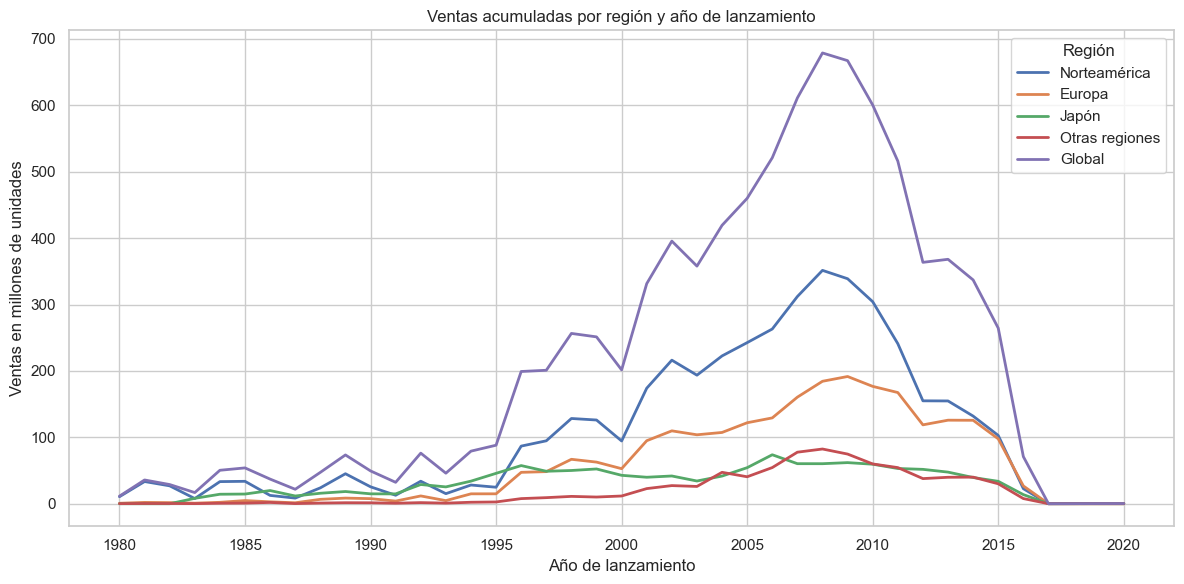

In [15]:
ventas_grafica = ventas_por_anio.melt(
    id_vars="Year",
    var_name="Region",
    value_name="Ventas"
)

nombres_regiones = {
    "NA_Sales": "Norteamérica",
    "EU_Sales": "Europa",
    "JP_Sales": "Japón",
    "Other_Sales": "Otras regiones",
    "Global_Sales": "Global"
}

ventas_grafica["Region"] = ventas_grafica["Region"].map(nombres_regiones)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=ventas_grafica,
    x="Year",
    y="Ventas",
    hue="Region",
    linewidth=2
)

plt.title("Ventas acumuladas por región y año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas en millones de unidades")
plt.legend(title="Región")
plt.tight_layout()

plt.savefig(
    "grafica_ventas_por_anio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Los videojuegos lanzados en 2008 reúnen las mayores ventas globales acumuladas del archivo. Norteamérica aporta el mayor volumen durante buena parte del periodo. En los lanzamientos posteriores a 2009 se observa una tendencia general descendente, con algunos repuntes.

Esto no demuestra una caída de las ventas anuales del mercado. Los videojuegos más recientes han tenido menos tiempo para acumular ventas y los años 2017 y 2020 cuentan con muy pocos registros.

## Videojuegos más vendidos por año de lanzamiento y región

Sumaré las ventas de cada videojuego en sus distintas plataformas para cada año de lanzamiento. Después identificaré los títulos con mayores ventas en cada región y a nivel global, incluyendo los empates.

In [16]:
# Sumar las ventas por año de lanzamiento y videojuego
ventas_juegos_anio = (
    df_limpio
    .groupby(["Year", "Name"])[columnas_ventas]
    .sum()
    .round(2)
    .reset_index()
)

# Buscar los líderes de cada año en los cinco mercados
resultados_juegos = []

for region in columnas_ventas:
    maximos = (
        ventas_juegos_anio
        .groupby("Year")[region]
        .transform("max")
    )

    lideres = ventas_juegos_anio[
        (ventas_juegos_anio[region] == maximos) &
        (maximos > 0)
    ].copy()

    lideres["Mercado"] = nombres_regiones[region]
    resultados_juegos.append(lideres)

juegos_mas_vendidos_anio = (
    pd.concat(resultados_juegos, ignore_index=True)
    .sort_values(["Year", "Mercado", "Name"])
    .reset_index(drop=True)
)

juegos_mas_vendidos_anio[
    ["Year", "Mercado", "Name"] + columnas_ventas
]

,Year,Mercado,Name,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1980,Europa,Asteroids,4.00,0.26,0.00,0.05,4.31
1,1980,Global,Asteroids,4.00,0.26,0.00,0.05,4.31
2,1980,Norteamérica,Asteroids,4.00,0.26,0.00,0.05,4.31
3,1980,Otras regiones,Asteroids,4.00,0.26,0.00,0.05,4.31
4,1981,Europa,Pitfall!,4.21,0.24,0.00,0.05,4.50
...,...,...,...,...,...,...,...,...
188,2017,Global,Phantasy Star Online 2 Episode 4: Deluxe Package,0.00,0.00,0.04,0.00,0.04
189,2017,Japón,Phantasy Star Online 2 Episode 4: Deluxe Package,0.00,0.00,0.04,0.00,0.04
190,2020,Global,Imagine: Makeup Artist,0.27,0.00,0.00,0.02,0.29
191,2020,Norteamérica,Imagine: Makeup Artist,0.27,0.00,0.00,0.02,0.29


## Plataformas con mayores ventas por año de lanzamiento y región

Sumaré las ventas de los videojuegos de cada plataforma por año de lanzamiento. Después identificaré las plataformas líderes en cada región y globalmente, incluyendo los empates. Las ventas están expresadas en millones de unidades.

In [17]:
# Sumar las ventas por año de lanzamiento y plataforma
ventas_plataforma_anio = (
    df_limpio
    .groupby(["Year", "Platform"])[columnas_ventas]
    .sum()
    .round(2)
    .reset_index()
)

# Buscar las plataformas líderes en los cinco mercados
resultados_plataformas = []

for region in columnas_ventas:
    maximos = (
        ventas_plataforma_anio
        .groupby("Year")[region]
        .transform("max")
    )

    lideres = ventas_plataforma_anio[
        (ventas_plataforma_anio[region] == maximos) &
        (maximos > 0)
    ].copy()

    lideres["Mercado"] = nombres_regiones[region]
    resultados_plataformas.append(lideres)

plataformas_lideres_anio = (
    pd.concat(resultados_plataformas, ignore_index=True)
    .sort_values(["Year", "Mercado", "Platform"])
    .reset_index(drop=True)
)

plataformas_lideres_anio[
    ["Year", "Mercado", "Platform"] + columnas_ventas
]

,Year,Mercado,Platform,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1980,Europa,2600,10.59,0.67,0.00,0.12,11.38
1,1980,Global,2600,10.59,0.67,0.00,0.12,11.38
2,1980,Norteamérica,2600,10.59,0.67,0.00,0.12,11.38
3,1980,Otras regiones,2600,10.59,0.67,0.00,0.12,11.38
4,1981,Europa,2600,33.40,1.96,0.00,0.32,35.77
...,...,...,...,...,...,...,...,...
182,2017,Global,PS4,0.00,0.00,0.03,0.00,0.03
183,2017,Japón,PS4,0.00,0.00,0.03,0.00,0.03
184,2020,Global,DS,0.27,0.00,0.00,0.02,0.29
185,2020,Norteamérica,DS,0.27,0.00,0.00,0.02,0.29


## Comparación de ventas entre géneros por año de lanzamiento

Compararé las ventas globales acumuladas de cada género según el año de lanzamiento de los videojuegos. La gráfica incluye los registros hasta 2016; los años 2017 y 2020 se excluyen por tener muy pocos registros.

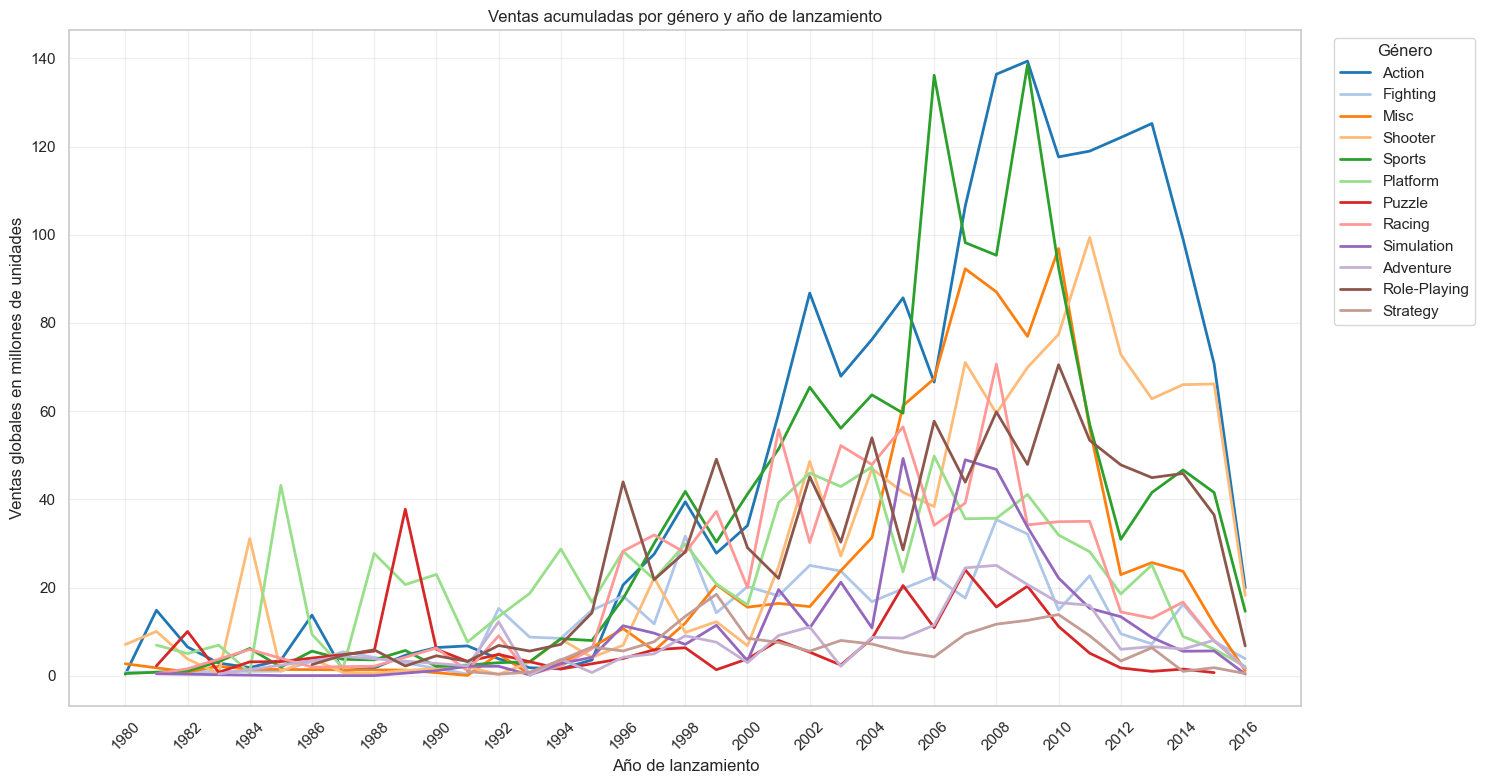

In [18]:
ventas_genero_anio = (
    df_limpio[df_limpio["Year"] <= 2016]
    .groupby(["Year", "Genre"])["Global_Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=ventas_genero_anio,
    x="Year",
    y="Global_Sales",
    hue="Genre",
    linewidth=2,
    palette="tab20"
)

plt.title("Ventas acumuladas por género y año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas globales en millones de unidades")
plt.xticks(range(1980, 2017, 2), rotation=45)
plt.legend(
    title="Género",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "grafica_generos_por_anio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Los videojuegos lanzados durante la década del 2000 concentran ventas acumuladas altas en varios géneros. Acción destaca durante varios años y alcanza su mayor valor entre los lanzamientos de 2009. Deportes y disparos también presentan cifras importantes.

Estos resultados corresponden a ventas acumuladas por año de lanzamiento, no a las ventas realizadas durante cada año.

## Insights adicionales

### Videojuegos con mayores ventas globales

Para conocer cuáles fueron los títulos más destacados del archivo, sumaré las ventas globales de cada videojuego y seleccionaré los diez primeros.

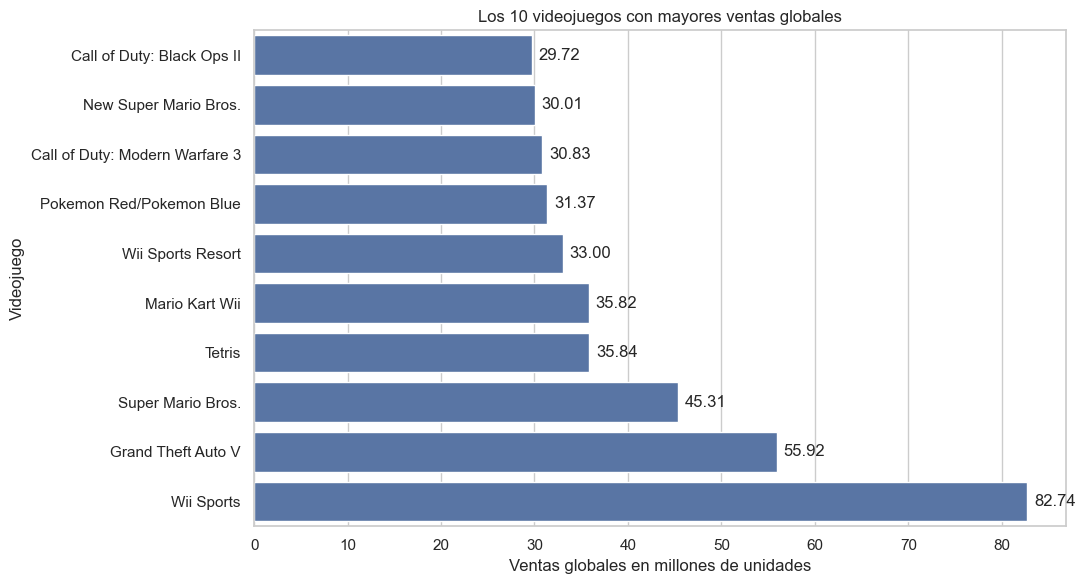

In [19]:
top_10_videojuegos = (
    df_limpio
    .groupby("Name")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_10_videojuegos = top_10_videojuegos.sort_values(
    "Global_Sales",
    ascending=True
)

plt.figure(figsize=(11, 6))

grafica = sns.barplot(
    data=top_10_videojuegos,
    x="Global_Sales",
    y="Name",
    color="#4C72B0"
)

plt.title("Los 10 videojuegos con mayores ventas globales")
plt.xlabel("Ventas globales en millones de unidades")
plt.ylabel("Videojuego")

for barra in grafica.patches:
    grafica.annotate(
        f"{barra.get_width():.2f}",
        (barra.get_width(), barra.get_y() + barra.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "grafica_videojuegos_mas_vendidos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Wii Sports ocupa el primer lugar con 82.74 millones de unidades vendidas. En segundo lugar se encuentra Grand Theft Auto V, con 55.92 millones. La diferencia entre ambos títulos muestra el alcance que tuvo Wii Sports dentro del mercado.

### Ventas de los géneros por región

Para conocer las diferencias entre mercados, compararé las ventas de cada género en Norteamérica, Europa, Japón y otras regiones.

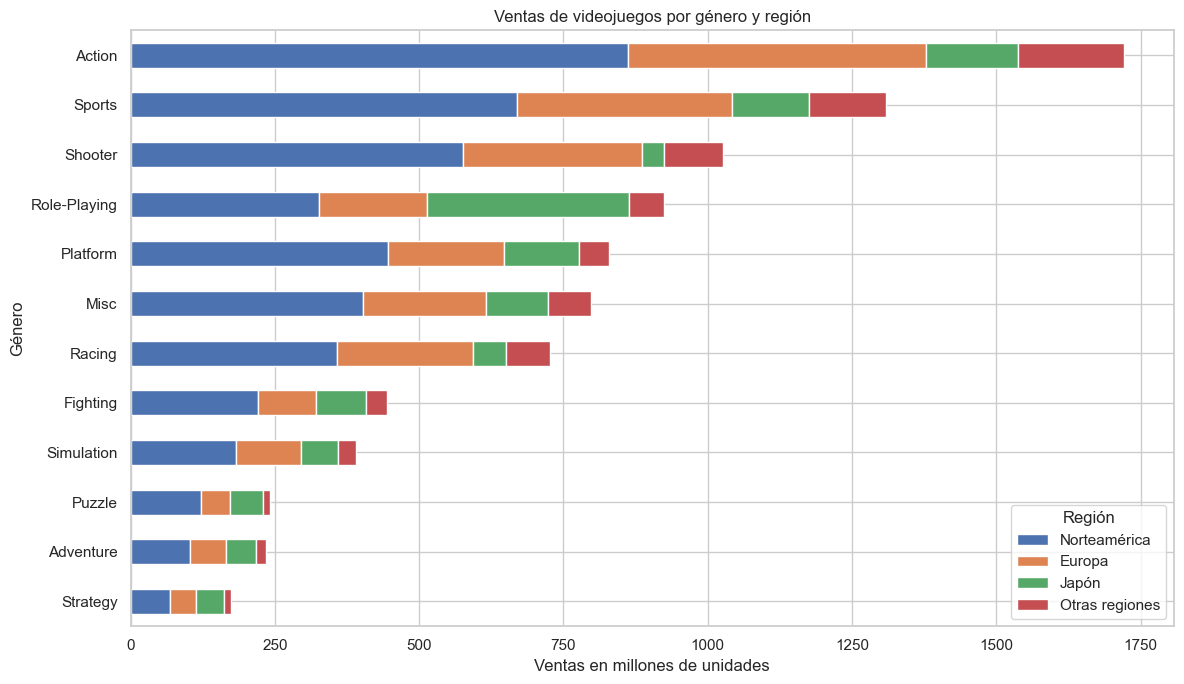

In [20]:
ventas_genero_region = (
    df_limpio
    .groupby("Genre")[
        ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
    ]
    .sum()
)

ventas_genero_region["Total"] = ventas_genero_region.sum(axis=1)

ventas_genero_region = ventas_genero_region.sort_values(
    "Total",
    ascending=True
)

datos_grafica_region = ventas_genero_region.drop(
    columns="Total"
).rename(
    columns={
        "NA_Sales": "Norteamérica",
        "EU_Sales": "Europa",
        "JP_Sales": "Japón",
        "Other_Sales": "Otras regiones"
    }
)

datos_grafica_region.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
)

plt.title("Ventas de videojuegos por género y región")
plt.xlabel("Ventas en millones de unidades")
plt.ylabel("Género")
plt.legend(title="Región")
plt.tight_layout()

plt.savefig(
    "grafica_generos_por_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Acción es el género con mayores ventas acumuladas, seguido de deportes y disparos. Norteamérica representa la mayor parte de las ventas en casi todos los géneros. En Japón destaca el género de rol, ya que su participación es mayor que la registrada en Norteamérica.

## Comparación del periodo 2013–2016

Seleccioné 2013–2016 como periodo de cuatro años consecutivos para este ejercicio. Excluí los registros aislados de 2017 y 2020 por su escasa cantidad. Esta selección no garantiza que la información de los años elegidos esté completa.

El archivo contiene ventas acumuladas y años de lanzamiento, no un historial de ventas anuales. Por eso, los porcentajes comparan las ventas de juegos lanzados en distintos años y no representan el crecimiento anual real del mercado.

In [32]:
df_ultimos_4 = df_limpio[
    df_limpio["Year"].between(2013, 2016)
].copy()

resumen_ultimos_4 = (
    df_ultimos_4
    .groupby("Year")
    .agg(
        Registros=("Name", "count"),
        Ventas_globales=("Global_Sales", "sum")
    )
    .round(2)
)

resumen_ultimos_4

,Registros,Ventas_globales
Year,,
2013,546,368.11
2014,582,337.05
2015,614,264.44
2016,344,70.93


### Crecimiento de los géneros

Para calcular el crecimiento de cada género, compararé sus ventas globales de 2013 con las registradas en 2016 mediante la función pct_change().

In [22]:
ventas_generos_4 = (
    df_ultimos_4
    .pivot_table(
        index="Genre",
        columns="Year",
        values="Global_Sales",
        aggfunc="sum",
        fill_value=0
    )
)

crecimiento_generos = (
    ventas_generos_4
    .pct_change(periods=3, axis=1, fill_method=None)[2016]
    .mul(100)
    .replace([float("inf"), float("-inf")], float("nan"))
    .dropna()
    .sort_values(ascending=False)
)

resultado_generos = ventas_generos_4.copy()
resultado_generos["Crecimiento_2013_2016"] = crecimiento_generos

resultado_generos.round(2)

Year,2013,2014,2015,2016,Crecimiento_2013_2016
Genre,,,,,
Action,125.22,99.02,70.70,19.91,-84.10
Adventure,6.61,6.06,8.03,1.81,-72.62
Fighting,7.21,16.15,7.78,3.86,-46.46
Misc,25.65,23.68,11.69,1.17,-95.44
Platform,25.12,8.89,6.05,2.07,-91.76
Puzzle,0.99,1.50,0.70,0.00,-100.00
Racing,13.04,16.69,7.92,1.64,-87.42
Role-Playing,44.92,45.86,36.44,6.76,-84.95
Shooter,62.80,66.00,66.15,18.22,-70.99


In [23]:
genero_mayor = crecimiento_generos.idxmax()
genero_menor = crecimiento_generos.idxmin()

print(
    "Género con mayor crecimiento:",
    genero_mayor,
    f"({crecimiento_generos.max():.2f}%)"
)

print(
    "Género con menor crecimiento:",
    genero_menor,
    f"({crecimiento_generos.min():.2f}%)"
)

Género con mayor crecimiento: Fighting (-46.46%)
Género con menor crecimiento: Puzzle (-100.00%)


Al comparar los lanzamientos de 2013 con los de 2016, ningún género presentó una variación positiva en sus ventas acumuladas. Fighting tuvo la menor disminución, con 46.46%. Puzzle obtuvo -100% porque no aparecen registros de ese género para 2016 y el cálculo utilizó cero.

Estas diferencias no demuestran una caída anual del mercado: también influyen la cobertura del archivo y el tiempo que cada videojuego ha tenido para acumular ventas.

### Crecimiento de las plataformas

Compararé las ventas acumuladas de los lanzamientos de 2013 y 2016 por plataforma mediante pct_change(), considerando las limitaciones del archivo.

In [24]:
ventas_plataformas_4 = (
    df_ultimos_4
    .pivot_table(
        index="Platform",
        columns="Year",
        values="Global_Sales",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(columns=[2013, 2014, 2015, 2016], fill_value=0)
)

crecimiento_plataformas = (
    ventas_plataformas_4
    .pct_change(periods=3, axis=1, fill_method=None)[2016]
    .mul(100)
    .replace([float("inf"), float("-inf")], float("nan"))
    .dropna()
    .sort_values(ascending=False)
)

resultado_plataformas = ventas_plataformas_4.copy()
resultado_plataformas["Crecimiento_2013_2016"] = crecimiento_plataformas

resultado_plataformas.round(2)

Year,2013,2014,2015,2016,Crecimiento_2013_2016
Platform,,,,,
3DS,55.88,43.14,26.99,6.60,-88.19
DS,1.96,0.02,0.00,0.00,-100.00
PC,12.83,13.39,8.07,2.60,-79.73
PS3,117.39,50.96,18.22,2.59,-97.79
PS4,24.76,98.76,115.30,39.25,58.52
PSP,3.19,0.24,0.12,0.00,-100.00
PSV,12.69,14.74,7.10,3.40,-73.21
Wii,9.36,4.44,1.55,0.00,-100.00
WiiU,21.84,22.51,16.38,3.29,-84.94


In [25]:
print(
    "Plataforma con mayor crecimiento:",
    crecimiento_plataformas.idxmax(),
    f"({crecimiento_plataformas.max():.2f}%)"
)

menor_crecimiento = crecimiento_plataformas.min()

print("Plataformas con menor crecimiento:")
print(
    crecimiento_plataformas[
        crecimiento_plataformas == menor_crecimiento
    ].round(2)
)

Plataforma con mayor crecimiento: PS4 (58.52%)
Plataformas con menor crecimiento:
Platform
DS    -100.0
PSP   -100.0
Wii   -100.0
Name: 2016, dtype: float64


Las ventas acumuladas de los juegos de PS4 lanzados en 2016 fueron 58.52% mayores que las de los lanzados en 2013. DS, PSP y Wii obtuvieron -100% porque no aparecen registros asociados a 2016 y el cálculo utilizó cero.

Esto no significa que esas plataformas hayan dejado de vender, ni representa el crecimiento anual de sus ventas.

### Variación de ventas por videojuego

Compararé los títulos que aparecen en 2013 y 2016, sumando sus ventas por nombre y año de lanzamiento. Esta comparación corresponde a versiones lanzadas en distintos años, no a las ventas anuales del mismo juego.

In [26]:
ventas_juegos_4 = (
    df_ultimos_4
    .pivot_table(
        index="Name",
        columns="Year",
        values="Global_Sales",
        aggfunc="sum"
    )
    .reindex(columns=[2013, 2014, 2015, 2016])
)

juegos_comparables = ventas_juegos_4[
    (ventas_juegos_4[2013] > 0) &
    (ventas_juegos_4[2016] > 0)
].copy()

crecimiento_juegos = (
    juegos_comparables
    .pct_change(periods=3, axis=1, fill_method=None)[2016]
    .mul(100)
)

resultado_juegos = juegos_comparables.copy()
resultado_juegos["Variacion_porcentual"] = crecimiento_juegos

resultado_juegos.sort_values(
    "Variacion_porcentual",
    ascending=False
).round(2)

Year,2013,2014,2015,2016,Variacion_porcentual
Name,,,,,
The Legend of Heroes: Trails in the Sky Third Chapter,0.01,NaN,NaN,0.02,100.00
Terraria,1.32,0.1,NaN,0.11,-91.67
Minecraft,9.20,14.1,NaN,0.43,-95.33


In [27]:
if crecimiento_juegos.empty:
    print("No hay videojuegos comparables entre ambos años.")
else:
    print("Videojuegos comparables:", len(crecimiento_juegos))

    print(
        "Mayor variación:",
        crecimiento_juegos.idxmax(),
        f"({crecimiento_juegos.max():.2f}%)"
    )

    print(
        "Menor variación:",
        crecimiento_juegos.idxmin(),
        f"({crecimiento_juegos.min():.2f}%)"
    )

Videojuegos comparables: 3
Mayor variación: The Legend of Heroes: Trails in the Sky Third Chapter (100.00%)
Menor variación: Minecraft (-95.33%)


Solo tres videojuegos cumplieron con el criterio de comparación. The Legend of Heroes: Trails in the Sky Third Chapter presentó la mayor variación, con 100%, al pasar de 0.01 a 0.02 millones de unidades. Aunque el porcentaje es alto, la diferencia es pequeña en cantidad de ventas. Minecraft tuvo la menor variación, con -95.33%.

Estos resultados comparan las ventas acumuladas de versiones lanzadas en años distintos, no el crecimiento anual de cada videojuego.

## Oportunidades de mercado

### Géneros con mayor participación en cada región

Revisaré qué porcentaje de las ventas de cada región corresponde a cada género entre los lanzamientos de 2013–2016. Esto puede ayudar a orientar el catálogo de una nueva plataforma, tomando en cuenta que se trata de información histórica y ventas acumuladas.

In [28]:
ventas_regionales_4 = (
    df_ultimos_4
    .groupby("Genre")[
        ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
    ]
    .sum()
)

participacion_generos = (
    ventas_regionales_4
    .div(ventas_regionales_4.sum(axis=0), axis=1)
    .mul(100)
    .rename(columns=nombres_regiones)
)

participacion_generos.round(2)

,Norteamérica,Europa,Japón,Otras regiones
Genre,,,,
Action,29.41,31.04,29.02,32.13
Adventure,1.62,2.09,4.16,2.07
Fighting,3.70,2.27,5.58,3.13
Misc,6.55,5.37,6.58,5.26
Platform,4.35,4.10,3.52,3.42
Puzzle,0.21,0.26,0.88,0.16
Racing,3.00,5.29,1.70,4.05
Role-Playing,10.04,9.04,35.63,9.07
Shooter,24.17,21.52,4.54,22.41


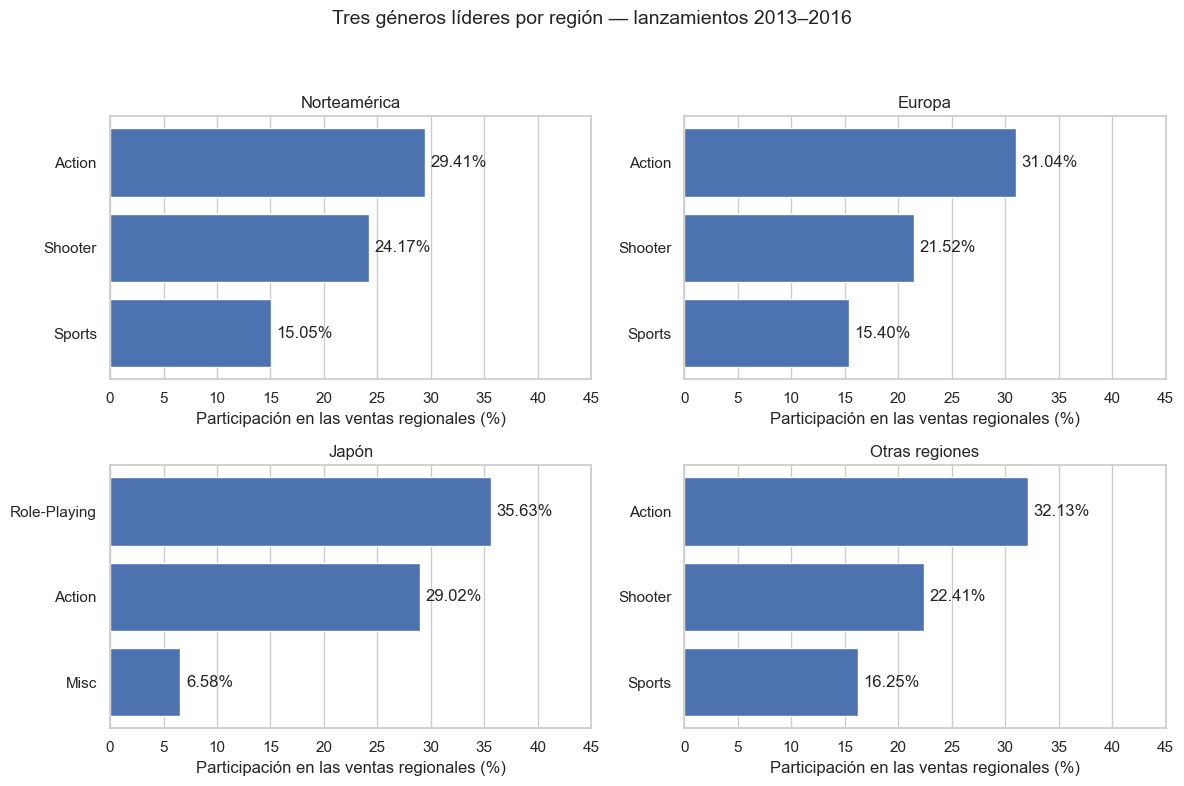

In [29]:
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))

for eje, region in zip(ejes.flat, participacion_generos.columns):
    top_3 = (
        participacion_generos[region]
        .nlargest(3)
        .sort_values()
    )

    barras = eje.barh(
        top_3.index,
        top_3.values,
        color="#4C72B0"
    )

    eje.bar_label(barras, fmt="%.2f%%", padding=4)
    eje.set_title(region)
    eje.set_xlabel("Participación en las ventas regionales (%)")
    eje.set_xlim(0, 45)
    eje.grid(axis="y", visible=False)

fig.suptitle(
    "Tres géneros líderes por región — lanzamientos 2013–2016",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "grafica_oportunidad_regional.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Acción lidera las ventas en Norteamérica, Europa y otras regiones, mientras que rol ocupa el primer lugar en Japón con 35.63%. Disparos también tiene una participación importante en Norteamérica y Europa.

Para una nueva plataforma, estos resultados sugieren evaluar un catálogo adaptado a cada región: acción y disparos para Norteamérica y Europa, y rol para Japón. Esta propuesta se basa en datos históricos y necesitaría información actual para confirmar la oportunidad.

### Ventas promedio y cantidad de registros por género

Compararé las ventas globales promedio y la cantidad de registros de cada género entre los lanzamientos de 2013 y 2016. Esto puede ayudar a identificar géneros que convendría evaluar para el catálogo.

Cada registro corresponde a un videojuego en una plataforma. Una menor cantidad de registros no significa necesariamente que exista poca competencia.

In [30]:
oportunidad_catalogo = (
    df_ultimos_4
    .groupby("Genre")
    .agg(
        Registros=("Name", "size"),
        Titulos_diferentes=("Name", "nunique"),
        Ventas_globales=("Global_Sales", "sum"),
        Promedio_por_registro=("Global_Sales", "mean"),
        Mediana_por_registro=("Global_Sales", "median")
    )
    .sort_values("Promedio_por_registro", ascending=False)
)

oportunidad_catalogo.round(3)

,Registros,Titulos_diferentes,Ventas_globales,Promedio_por_registro,Mediana_por_registro
Genre,,,,,
Shooter,172,68,213.17,1.239,0.455
Sports,208,73,144.35,0.694,0.210
Platform,71,37,42.13,0.593,0.240
Racing,82,34,39.29,0.479,0.110
Role-Playing,280,198,133.98,0.478,0.125
Fighting,78,46,35.00,0.449,0.135
Action,708,367,314.85,0.445,0.115
Misc,140,95,62.19,0.444,0.125
Simulation,53,42,20.23,0.382,0.100


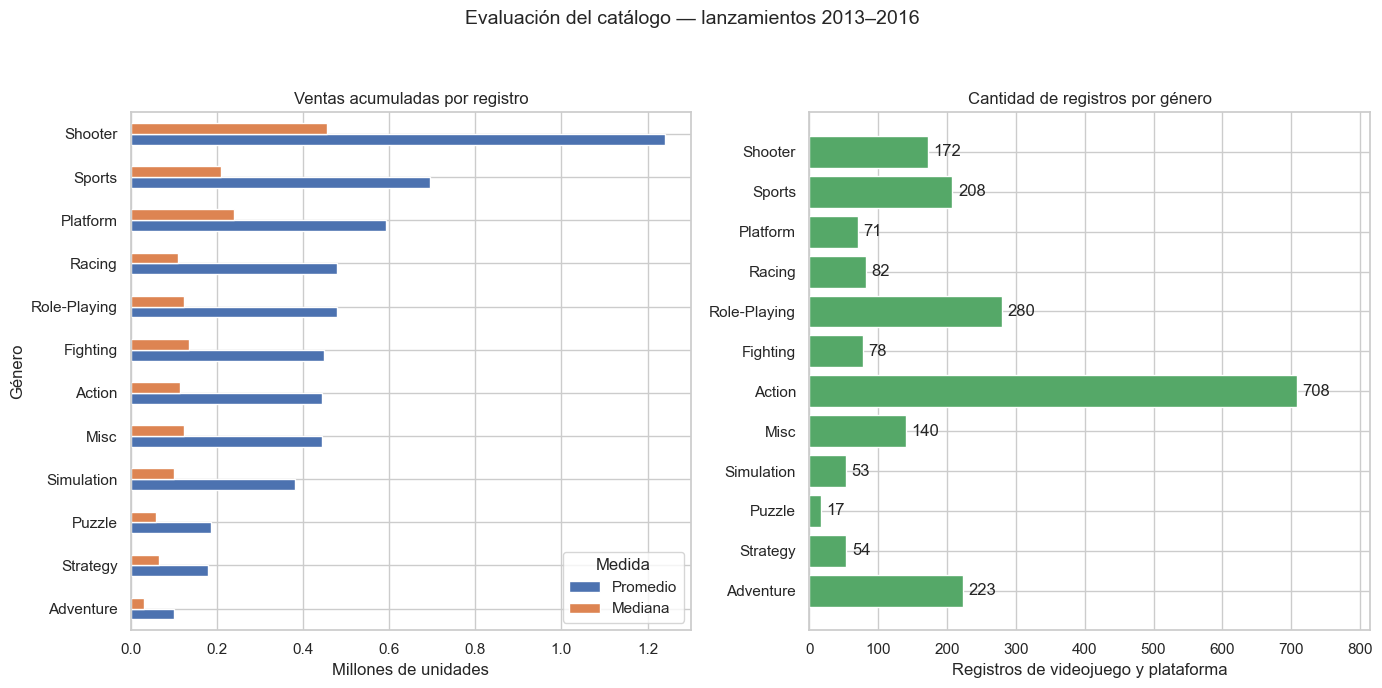

In [31]:
datos_catalogo = oportunidad_catalogo.sort_values(
    "Promedio_por_registro",
    ascending=True
)

fig, ejes = plt.subplots(1, 2, figsize=(14, 7))

datos_catalogo[
    ["Promedio_por_registro", "Mediana_por_registro"]
].rename(
    columns={
        "Promedio_por_registro": "Promedio",
        "Mediana_por_registro": "Mediana"
    }
).plot.barh(
    ax=ejes[0],
    color=["#4C72B0", "#DD8452"]
)

ejes[0].set_title("Ventas acumuladas por registro")
ejes[0].set_xlabel("Millones de unidades")
ejes[0].set_ylabel("Género")
ejes[0].legend(title="Medida")

barras = ejes[1].barh(
    datos_catalogo.index,
    datos_catalogo["Registros"],
    color="#55A868"
)

ejes[1].bar_label(barras, padding=4)
ejes[1].set_xlim(0, datos_catalogo["Registros"].max() * 1.15)
ejes[1].set_title("Cantidad de registros por género")
ejes[1].set_xlabel("Registros de videojuego y plataforma")
ejes[1].set_ylabel("")

fig.suptitle(
    "Evaluación del catálogo — lanzamientos 2013–2016",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "grafica_oportunidad_catalogo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Disparos tiene el mayor promedio de ventas por registro, con 1.239 millones, y la mayor mediana, con 0.455 millones. Plataformas también destaca: presenta un promedio de 0.593 millones y una mediana de 0.240 millones, con 71 registros.

Estos resultados sugieren evaluar ambos géneros para el catálogo. Sin embargo, los promedios superan a las medianas, por lo que algunos títulos con ventas altas influyen en los resultados. Tener menos registros tampoco garantiza menor competencia o mayor rentabilidad.

## Conclusión

En este análisis trabajé con 16,327 registros con año de lanzamiento disponible, correspondientes a 11,360 títulos diferentes, 12 géneros y 31 plataformas. Acción tuvo las mayores ventas globales acumuladas entre los géneros, mientras que Wii Sports encabezó la lista de videojuegos.

Al revisar los lanzamientos de 2013–2016, encontré diferencias entre regiones. Acción y disparos destacaron en Norteamérica y Europa, mientras que rol tuvo la mayor participación en Japón. Disparos también presentó el mayor promedio y la mayor mediana de ventas por registro, por lo que sería un género a evaluar para el catálogo de una nueva plataforma.

Los resultados sirven como una referencia histórica. El archivo contiene ventas acumuladas por año de lanzamiento, así que las variaciones calculadas no representan el crecimiento anual real del mercado. Para tomar una decisión de negocio también necesitaría información actual sobre preferencias, costos y competencia.